In [42]:
using CSV
using DataFrames
using Plots
using LaTeXStrings
using Statistics
using CurveFit
using SciPy

In [43]:
gr()
# plotly()
# theme(:dark; palette = palette(:darktest))
# theme(:light; palette = palette(:darktest))

Plots.GRBackend()

In [44]:
readdir("data")

13-element Vector{String}:
 "Old Data"
 "Sat Apr  4 13:03:47 2026 First test voltmeter only.csv"
 "Sat Apr  4 13:09:04 20263.3V calibration.csv"
 "Sat Apr  4 13:10:14 20261uF voltmeter resistance.csv"
 "Sat Apr  4 13:21:13 20261uF 1 M Ohm .csv"
 "Sat Apr  4 13:43:49 20261uF 2 M Ohm .csv"
 "Sat Apr  4 13:51:26 20261uF 100 K Ohm .csv"
 "Sat Apr  4 13:53:53 20261uF 100 K Ohm + 100K Ohm .csv"
 "Sat Apr  4 13:55:33 20261uF 10 K Ohm.csv"
 "Sat Apr  4 13:56:41 20261uF Voltmeter Again.csv"
 "Sat Apr  4 14:07:17 20261uF 5(1 M Ohm) + 6(100K Ohm).csv"
 "Sat Apr  4 14:12:25 20261uF 6(1 M Ohm) + 6(100K Ohm).csv"
 "Sat Apr  4 14:17:56 20261uF Just the divider and arduino.csv"

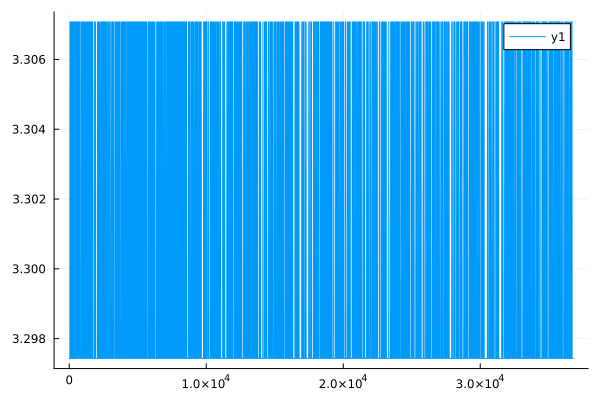

print device already activated


In [45]:
calibration = CSV.File("data/Sat Apr  4 13:09:04 20263.3V calibration.csv")
trimmed_voltages = calibration.voltages[begin + 1: end]

voltage_norm = 3.30 / mean(trimmed_voltages)
voltage_error = std(trimmed_voltages * voltage_norm)

plot(calibration.times[begin + 1: end], trimmed_voltages * voltage_norm)

In [46]:
voltage_norm * 2

0.019283233701886185

In [47]:
voltage_error = (voltage_norm * 2)

0.019283233701886185

In [48]:

mutable struct Trial
           name::String
           filename::String
           startcut::Int32
            fitoffcut::Int32
            times
            voltages
            sol
       end

trials = [
    Trial("voltmeter", "data/Sat Apr  4 13:10:14 20261uF voltmeter resistance.csv", 566, 1, nothing, nothing, nothing), 
    
#  "Sat Apr  4 13:51:26 20261uF 100 K Ohm .csv"
#  "Sat Apr  4 13:53:53 20261uF 100 K Ohm + 100K Ohm .csv"
#  "Sat Apr  4 13:55:33 20261uF 10 K Ohm.csv"

    
    Trial("100 KΩ", "data/Sat Apr  4 13:51:26 20261uF 100 K Ohm .csv", 928, 1, nothing, nothing, nothing),
    Trial("200 KΩ", "data/Sat Apr  4 13:53:53 20261uF 100 K Ohm + 100K Ohm .csv", 1085, 1, nothing, nothing, nothing),
    # Trial("10 KΩ", "data/Sat Apr  4 13:55:33 20261uF 10 K Ohm.csv", 1, 1, nothing, nothing, nothing),
    

    Trial("1 MΩ", "data/Sat Apr  4 13:21:13 20261uF 1 M Ohm .csv", 1107, 1, nothing, nothing, nothing), 
    Trial("2 MΩ", "data/Sat Apr  4 13:43:49 20261uF 2 M Ohm .csv", 630, 1, nothing, nothing, nothing), 
    Trial("5.5 MΩ", "data/Sat Apr  4 14:07:17 20261uF 5(1 M Ohm) + 6(100K Ohm).csv", 1004, 1, nothing, nothing, nothing), 
    Trial("6.6 MΩ", "data/Sat Apr  4 14:12:25 20261uF 6(1 M Ohm) + 6(100K Ohm).csv", 1079, 1, nothing, nothing, nothing), 
    Trial("Just divider", "data/Sat Apr  4 14:17:56 20261uF Just the divider and arduino.csv", 1950, 1, nothing, nothing, nothing), 
]

# arduino_trial = Trial("Arduino Resistance", "Wed Apr  1 23:51:39 2026Just the arduino.csv", 1, 1, nothing, nothing, nothing) 


8-element Vector{Trial}:
 Trial("voltmeter", "data/Sat Apr  4 13:10:14 20261uF voltmeter resistance.csv", 566, 1, nothing, nothing, nothing)
 Trial("100 KΩ", "data/Sat Apr  4 13:51:26 20261uF 100 K Ohm .csv", 928, 1, nothing, nothing, nothing)
 Trial("200 KΩ", "data/Sat Apr  4 13:53:53 20261uF 100 K Ohm + 100K Ohm .csv", 1085, 1, nothing, nothing, nothing)
 Trial("1 MΩ", "data/Sat Apr  4 13:21:13 20261uF 1 M Ohm .csv", 1107, 1, nothing, nothing, nothing)
 Trial("2 MΩ", "data/Sat Apr  4 13:43:49 20261uF 2 M Ohm .csv", 630, 1, nothing, nothing, nothing)
 Trial("5.5 MΩ", "data/Sat Apr  4 14:07:17 20261uF 5(1 M Ohm) + 6(100K Ohm).csv", 1004, 1, nothing, nothing, nothing)
 Trial("6.6 MΩ", "data/Sat Apr  4 14:12:25 20261uF 6(1 M Ohm) + 6(100K Ohm).csv", 1079, 1, nothing, nothing, nothing)
 Trial("Just divider", "data/Sat Apr  4 14:17:56 20261uF Just the divider and arduino.csv", 1950, 1, nothing, nothing, nothing)

In [49]:
function clean_data(voltages, times, startcut)
	normalizedVoltages = voltages .* voltage_norm
	normalizedtimes = times ./ (1000)

    slicedvoltages = normalizedVoltages[startcut:end]
	slicedtimes = normalizedtimes[startcut:end]	

	start = findall(slicedvoltages .== maximum(slicedvoltages))[begin]

	slicedvoltages = slicedvoltages[start:end]
	slicedtimes = slicedtimes[start:end]	

	stop = findall(slicedvoltages .== minimum(slicedvoltages))[begin] - 1 # minus one to prevent log inf

	slicedvoltages = slicedvoltages[begin:stop]
	slicedtimes = slicedtimes[begin:stop]

	slicedtimes = slicedtimes .- minimum(slicedtimes)

	slicedtimes, slicedvoltages
end

clean_data (generic function with 1 method)

In [50]:

for trial in trials
    data = CSV.File(trial.filename)
    trial.times, trial.voltages = clean_data(data.voltages, data.times, trial.startcut)
end

# data = CSV.File(arduino_trial.filename)
# arduino_trial.times, arduino_trial.voltages = clean_data(data.voltages, data.times, arduino_trial.startcut)

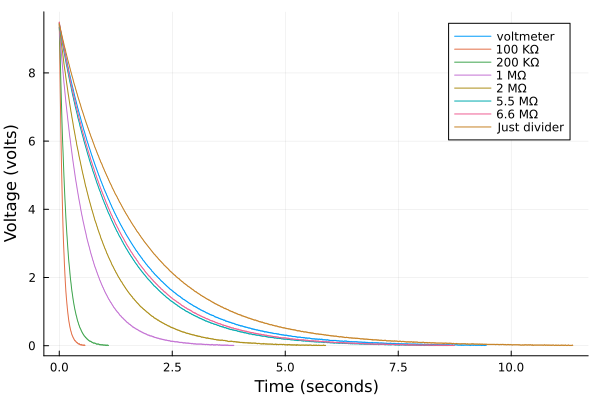

In [51]:

p = plot()

for trial in trials
    # if trial.name == "Arduino Resistance"
    #     continue
    # end
    plot!(trial.times, trial.voltages, label = trial.name, ribbon = voltage_error)
end
yaxis!("Voltage (volts)")
xaxis!("Time (seconds)")
# xlims!((:auto, 1))

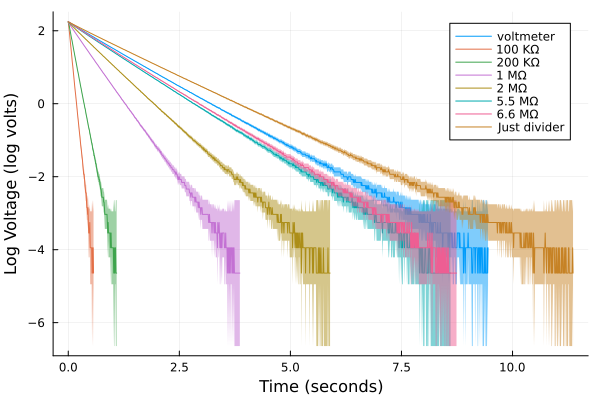

In [52]:
p = plot()

for trial in trials
    plot!(trial.times, log.(trial.voltages), label = trial.name, ribbon = voltage_error ./ trial.voltages)
end
yaxis!("Log Voltage (log volts)")
xaxis!("Time (seconds)")


In [53]:
p = plot(size=(800, 550))

# layout = Layout(legend=attr(x=1, y=0.5)) # Mid-right

p2 = plot(legend=:outerright, size=(800, 550))

RC = []
dRC = []

x = 0.4
brighter = RGBA(x,x,x, 1)

for trial in trials

    log_uncertainty = voltage_error ./ trial.voltages

    data = SciPy.odr.RealData(trial.times, log.(trial.voltages), sy = log_uncertainty)
    
    odr_obj = SciPy.odr.ODR(data, SciPy.odr.unilinear);
    
    output = odr_obj.run();
    
    println(output.beta)
    b = output.beta[1]
    a = output.beta[2]

    push!(RC, -1/b)
    push!(dRC, output.sd_beta[1] / b^2)

    plot!(p, trial.times, trial.voltages, label=trial.name * " data", ribbon = voltage_error)
    plot!(p, trial.times, exp(a) .* exp.(b .* trial.times), label= trial.name * " model", ls= :dot, lc = p.series_list[end].plotattributes[:linecolor] + brighter)

    residuals = @. log(trial.voltages) - (a + b * trial.times)

    ndof = length(trial.voltages) - length(output.beta) 
    chi_squared = sum((residuals ./ log_uncertainty) .^ 2) / ndof

    println("b ", output.beta[1], " pm ", output.sd_beta[2], "Chi-squared: ", chi_squared)

    plot!(p2, trial.times, log.(trial.voltages), label=trial.name * " data", ribbon = log_uncertainty)
    plot!(p2, trial.times, a .+ b .* trial.times, label= trial.name * " model", ls= :dot, lc = p2.series_list[end].plotattributes[:linecolor] + brighter)

end

title!(p, "Voltage Decay of Capacitor in RC Circuit")
yaxis!(p, "Voltage (volts)")
xaxis!(p, "Time (seconds)")

title!(p2, "Log of Voltage Decay of Capacitor in RC Circuit")
yaxis!(p2, "Log Voltage (log volts)")
xaxis!(p2, "Time (seconds)")

savefig(p2, "figures/log_voltage_decay.svg")

[-0.6716775553593921, 2.183392070156561]
b -0.6716775553593921 pm 0.003916500507323266Chi-squared: 22.43146652396529
[-12.056570709070655, 2.2635507212783503]
b -12.056570709070655 pm 0.03516212300919456Chi-squared: 2.201423235135911
[-6.267966181784699, 2.2486220622580695]
b -6.267966181784699 pm 0.020850184693746877Chi-squared: 4.450887842435037
[-1.7142569616936874, 2.2155470473645766]
b -1.7142569616936874 pm 0.010295579336888188Chi-squared: 2.261742476063339
[-1.133622013464481, 2.207937174159267]
b -1.133622013464481 pm 0.006866299811562451Chi-squared: 5.296594519072549
[-0.7753431564618983, 2.2137249818153246]
b -0.7753431564618983 pm 0.004843172573563672Chi-squared: 3.97521703479989
[-0.74792202857458, 2.221072951650793]
b -0.74792202857458 pm 0.0047801666709891034Chi-squared: 3.883601859262752
[-0.5692822109615099, 2.197681279100868]
b -0.5692822109615099 pm 0.003570349928153607Chi-squared: 11.014539047286572


GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_CO

"/Users/sam/Desktop/Science One For Real/physics/SCIE001Physics/figures/log_voltage_decay.svg"

GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_COLOR_REP
GKS: Colour is invalid in routine SET_CO

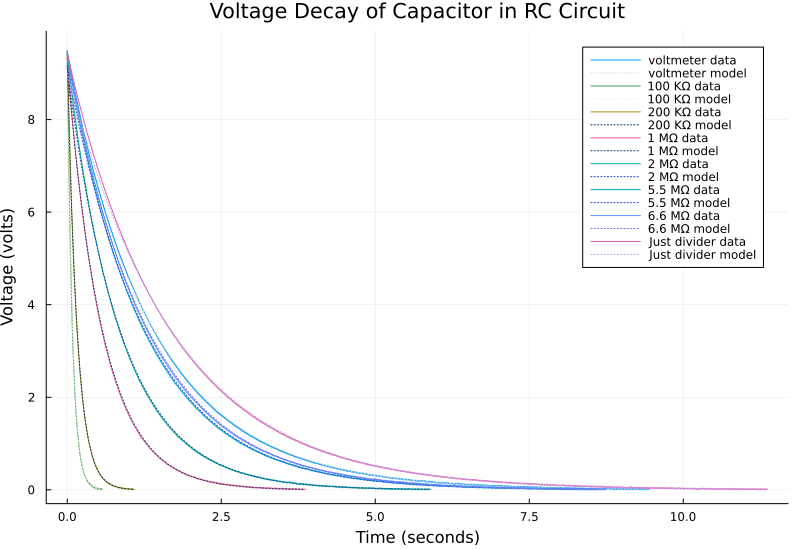

In [54]:
savefig(p, "figures/voltage_decay.svg")
p


In [55]:
dRC

8-element Vector{Any}:
 0.001753542616799904
 0.0007094426507555267
 0.0008185870581372401
 0.0016145780040076863
 0.0016787642603976578
 0.0018072619618017683
 0.0018598149485943524
 0.0018783279885394805

In [56]:
actual_resistance_over_cap = [0.0998e6, 0.2e6, 0.997e6, 1.997e6, 5.6e6, 6.59e6, -Inf]

actual_resistance_over_cap = @. 1 / ( (1/actual_resistance_over_cap) + (1/1.995e6)) 

voltmeter_RC = RC[begin]
dvoltmeter_RC = dRC[begin]

cut_RC = RC[begin+1:end]
cut_dRC = dRC[begin+1:end]


7-element Vector{Any}:
 0.0007094426507555267
 0.0008185870581372401
 0.0016145780040076863
 0.0016787642603976578
 0.0018072619618017683
 0.0018598149485943524
 0.0018783279885394805

In [57]:
actual_resistance_over_cap

7-element Vector{Float64}:
  95045.35039144549
 181776.76537585421
 664777.7406417112
 997999.7494989982
      1.4709677419354839e6
      1.5313977868375073e6
      1.9950000000000002e6

In [58]:
# println(length(actual_resistance_over_cap), " ", length(RC[begin+1:end]), " ", length(dRC[begin+1:end]))


data = SciPy.odr.RealData(actual_resistance_over_cap, cut_RC, sy = cut_dRC)

odr_obj = SciPy.odr.ODR(data, SciPy.odr.unilinear);

output = odr_obj.run();

println(output.beta)
b = output.beta[1]
a = output.beta[2]

residuals = @. cut_RC - (a + b * actual_resistance_over_cap)

ndof = length(cut_RC) - length(output.beta) 
chi_squared = sum((residuals ./ cut_dRC) .^ 2) / ndof

println("b ", output.beta[1], " pm ", output.sd_beta[2], "Chi-squared: ", chi_squared)

C = output.beta[1]
dC = output.sd_beta[1]

# plot(actual_resistance_over_cap, cut_RC, label= "data", yerror = cut_dRC, marker=:circle, line = false)
plot(actual_resistance_over_cap, cut_RC, label= "data", marker=:circle,  linealpha = 0, legend=:bottomright)
plot!(actual_resistance_over_cap, a .+ b .* actual_resistance_over_cap, label= "model", ls= :dot)


# s = scatter(actual_resistance_over_cap, cut_RC, yerror = cut_dRC, label = "Measured RC", marker=:circle)

xlabel!("Resistance over Capacitor (ohms)")
ylabel!("Measured RC (seconds)")
title!("Measured RC vs Resistance over Capacitor")

savefig("figures/RC_to_R.svg")


[8.784427431002238e-7, -0.00030521408079794976]
b 8.784427431002238e-7 pm 0.0015652932446422756Chi-squared: 7.368709807436547


"/Users/sam/Desktop/Science One For Real/physics/SCIE001Physics/figures/RC_to_R.svg"

In [59]:
@. (1/ ( (1/(RC / C)) - (1/ 1.995e6) )) 

8-element Vector{Float64}:
      1.1264160846957825e7
  99110.44497221973
 199808.33291538156
 995397.8229814625
      2.0219629730217673e6
      5.560453809536674e6
      6.420399589070793e6
     -8.53747986652356e8

In [60]:
@. (1/ ( (1/(actual_resistance_over_cap)) - (1/ 1.995e6) ))  

7-element Vector{Float64}:
  99800.0
 199999.99999999997
 996999.9999999999
      1.9970000000000005e6
      5.599999999999998e6
      6.589999999999998e6
     Inf

In [84]:
println("Capacitance: ", C / 1e-6, " uF pm ", dC / 1e-6 , " uF")

Capacitance: 0.8784427431002239 uF pm 0.002020286388153829 uF


In [62]:
dvoltmeter_RC

0.001753542616799904

In [85]:
voltmeter_R = @. (1/ ( (1/(voltmeter_RC / C)) - (1/ 1.995e6) )) 

dvoltmeter_R = sqrt( (dvoltmeter_RC / C)^2 + (-dC * dvoltmeter_RC / C^2 )^2 )

# sqrt(((C * dvoltmeter_RC) / (voltmeter_RC^2 * ((C/voltmeter_RC) - (1/1.995e6))^2))^2 + ((dC) / (voltmeter_RC * ((C/voltmeter_RC) - (1/1.995e6))^2))^2)

println("Voltmeter Resistance: ", voltmeter_R / 1e6, "mo pm ", dvoltmeter_R / 1e6 , "mo")

Voltmeter Resistance: 11.264160846957825mo pm 0.001996199829848517mo


In [64]:
p.series_list[end].plotattributes[:linecolor] + RGBA(0.2, 0.2, 0.2, 0.2)

In [65]:
# plot(trials[1].times, trials[1].voltages, label=trials[1].name * " data").series_list[1].plotattributes[:linecolor]

In [66]:
trials[1].fitoffcut = 0
# trials[2].fitoffcut = 1500
# trials[3].fitoffcut = 13000
# trials[4].fitoffcut = 10


0

In [67]:
# log.(trials[end].voltages)[begin: end - trials[end].fitoffcut]

In [68]:
for trial in trials
    
    # offcut = trial.fitoffcut # 1800
    # println(offcut)
    y = log.(trial.voltages) # [begin: end - offcut] # @. 1.0 - 2.0 * slicedtimes + rand()  # y = 1 + 2x
    
    prob = CurveFitProblem(trial.times, y)
    trial.sol = solve(prob, LinearCurveFitAlgorithm())
end

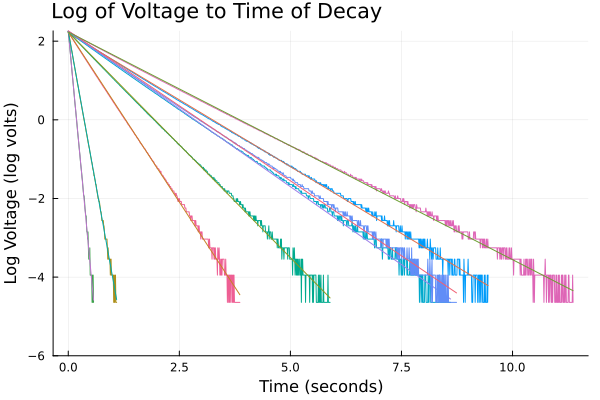

In [69]:
p = plot(titlelocation = :left, legend = false, ) #, legend=:topright)

for trial in trials
    plot!(trial.times, [log.(trial.voltages), trial.sol.(trial.times)], label=[(trial.name * " data") (trial.name * " model")])
end

title!("Log of Voltage to Time of Decay")
yaxis!("Log Voltage (log volts)")
xaxis!("Time (seconds)")
ylims!((-6, :auto))

# savefig("Log of Voltage to Time of Decay.html")

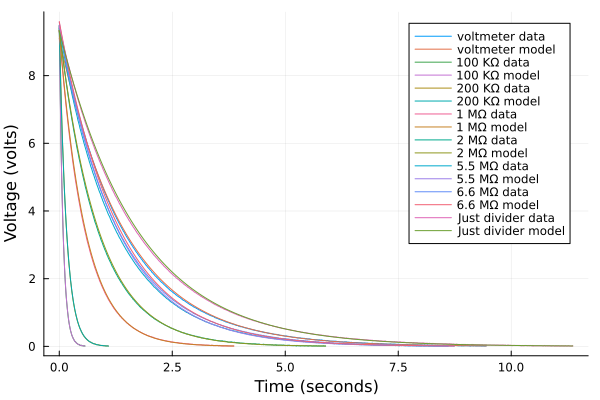

In [70]:
p = plot()

for trial in trials
    plot!(trial.times, [trial.voltages, exp.(trial.sol.(trial.times))], label=[(trial.name * " data") (trial.name * " model")])
end

yaxis!("Voltage (volts)")
xaxis!("Time (seconds)")

# xlims!((:auto, 1))

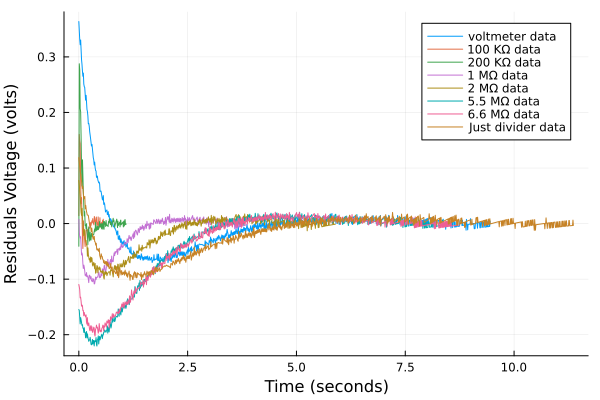

In [71]:
p = plot()

for trial in trials
    plot!(trial.times, [trial.voltages - exp.(trial.sol.(trial.times))], label=[(trial.name * " data") (trial.name * " model")])
end

yaxis!("Residuals Voltage (volts)")
xaxis!("Time (seconds)")


In [72]:
# p = plot()

# for trial in trials
#     plot!(trial.times[begin: end - trial.fitoffcut], [log.(trial.voltages[begin: end - trial.fitoffcut]), trial.sol.(trial.times[begin: end - trial.fitoffcut])], label=[(trial.name * " data") (trial.name * " model")])
# end

In [73]:
capacitance = 1e-6

actual_resistance_over_cap = [1e6, 2e6, 5.6e6, 6.6e6, -Inf]

actual_resistance_over_cap = @. 1 / ( (1/actual_resistance_over_cap) + (1/1.995e6)) 

total_resistance_value = []

for trial in trials[begin+1:end]
    slope = trial.sol.u[1]
    intercept = trial.sol.u[2]
    R = (-1 / (slope)) / capacitance

    push!(total_resistance_value, R)
    
    println(slope, " " * trial.name * " Predicted Total Resistance: ", R / 1e6, " Mega Ohms | ", R , " Ohms")

    if trial.name == "(1M, 1M) Just divider "
        println("Predicted actual resistance:", R*1.167646404806601 )
        continue
    end
    
    println("Predicted actual resistance:", (1/ ( (1/(R*1.167646404806601)) - (1/ 1.995e6) )))
end

-12.006836861398407 100 KΩ Predicted Total Resistance: 0.08328588216393343 Mega Ohms | 83285.88216393343 Ohms
Predicted actual resistance:102231.86516042924
-6.254491786230994 200 KΩ Predicted Total Resistance: 0.15988509285461994 Mega Ohms | 159885.09285461993 Ohms
Predicted actual resistance:205962.97524206917
-1.7295645866571432 1 MΩ Predicted Total Resistance: 0.5781802007942205 Mega Ohms | 578180.2007942206 Ohms
Predicted actual resistance:1.0204218145973054e6
-1.1475944123114166 2 MΩ Predicted Total Resistance: 0.8713880002132978 Mega Ohms | 871388.0002132978 Ohms
Predicted actual resistance:2.0765246405036475e6
-0.792009667753708 5.5 MΩ Predicted Total Resistance: 1.2626108502389783 Mega Ohms | 1.2626108502389784e6 Ohms
Predicted actual resistance:5.648355512678197e6
-0.7623873192030259 6.6 MΩ Predicted Total Resistance: 1.3116692458176853 Mega Ohms | 1.3116692458176853e6 Ohms
Predicted actual resistance:6.593113868071918e6
-0.5788888207368844 Just divider Predicted Total Resist

In [74]:
plot(actual_resistance_over_cap, total_resistance_value)
yaxis!("Calculated total_resistance_value ")
xaxis!("actual_resistance_over_cap with parrelel taken into account")


print device already activated
print device already activated


In [75]:
ratios = actual_resistance_over_cap ./ total_resistance_value
println(ratios)
mean(ratios)

DimensionMismatch: DimensionMismatch: arrays could not be broadcast to a common size: a has axes Base.OneTo(5) and b has axes Base.OneTo(7)

In [76]:
for trial in [trials[begin]]
    slope = trial.sol.u[1]
    intercept = trial.sol.u[2]
    R = (-1 / (slope)) / capacitance
    
    println(slope, " " * trial.name * " Predicted Total Resistance: ", R / 1e6, " Mega Ohms | ", R , " Ohms")
    println("Predicted actual resistance:", (1/ ( (1/(R*1.167646404806601)) - (1/ 1.995e6) )))
end

-0.6797511096680446 voltmeter Predicted Total Resistance: 1.4711266900150388 Mega Ohms | 1.4711266900150387e6 Ohms
Predicted actual resistance:1.2360665024610162e7


In [77]:
(1 / 0.8501132355319658) * 1.832116012150789

2.155143498035678

In [78]:
Rard = 1 / ((1/1e5) - (1 / 814631.9130169074))

113993.2177920571

In [79]:

p = plot()

plot!(arduino_trial.times, arduino_trial.voltages, label = arduino_trial.name)

yaxis!("Voltage (volts)")
xaxis!("Time (seconds)")

UndefVarError: UndefVarError: `arduino_trial` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [80]:

p = plot()

plot!(arduino_trial.times, log.(arduino_trial.voltages), label = arduino_trial.name)

yaxis!("Log Voltage (log volts)")
xaxis!("Time (seconds)")

UndefVarError: UndefVarError: `arduino_trial` not defined in `Main`
Suggestion: check for spelling errors or missing imports.